# Homework 6

In [1]:
from scipy.stats import binom, geom, poisson, uniform
from scipy.integrate import quad
import matplotlib.pyplot as plt
import numpy as np

## Aufgabe 5.2.c)

In [30]:
n, p = 100, 0.25
k = np.arange(0, 101)
cdf = binom.cdf(k, n, p)
P = sum(binom.pmf(i, n, p) for i in range(21)) # P(A <= 20)
print(f"{P:.4f}")

0.1488


## d)

In [31]:
P = geom.sf(10, p) # P(W > 10) => 1 - P(W ≤ 10)
print(f"{P:.4f}")

0.0563


## Aufgabe 5.3

### P(X=5); Po(5)

# Merke: für <= : cdf, für > : sf, für = : pmf

In [33]:
# a)
P = poisson.pmf(5, 5)
print(f"{P:.4f}")


# b) P(X>5)
P = poisson.sf(5, 5)
print(f"{P:.4f}")

0.1755
0.3840


## Aufgabe 5.9

### p = 0.7, unabhängig, Zufallsvariable F, E(F) = lambda = 40, 
### Zufallsvariable R, lambda_R = 20;
### B : Anzahl F funktionierende Beleuchtung, Serie à 10 F
### E : Anzahl F => erste nicht funktionierende Beleuchtung
### F : Anzahl F / min
### R : Anzahl F / min über Rheinbrücke

## a)
### B ~ Bin(10, 0.7), E(B) = 10 * 0.7 = 7; E ~ Geom(0.3) (0.3 := !p(B) => Gegenwahrscheinlichkeit von p(B)).
### E(E) = 1/0.3 = 10/3

## b) P(E|X=5)

In [2]:
P = geom.pmf(5, 0.3)
print(f"{P:.5f}")

0.07203


## c) P(B|X>=5)

In [38]:
P = binom.sf(4, 10, 0.7)
print(f"{P:.4f}")

0.9527


## d) 95 % höchstens eine funktionierende Beleuchtung

In [9]:
#bin.ppf(0.95,10) # 95% quantile

### B(P=0.95) = 1

## e) 
### Po(40) => E(F) = lambda = 40; I: P(30|E(F));
### II: Po(20) => E(R) = lambda_R = 20; P(30|E(R))
### III: P(30|E(R)||E(F))

In [49]:
# I
P_F = poisson.cdf(30, 40)
# II
P_R = poisson.cdf(30, 20)
# III
P_F_R = poisson.cdf(30, 60)
print(f"P(F) = {P_F:.4f}, P(R) = {P_R:.4f}, P(F OR R) = {P_F_R}")

P(F) = 0.0617, P(R) = 0.9865, P(F OR R) = 1.417434333349215e-05


# Übungsblatt 6

## Aufgabe 6.1
P(X) = 0 für x <= 2, X/2 - 1 für 2 < x <= 4, 1 für x >= 4, X ~ Bin(2,4)
### Teilaufgabe 6.1.1
Dichtefunktion der Verteilungsfunktion D = f(x) = F'(x) bzw. Ableitung

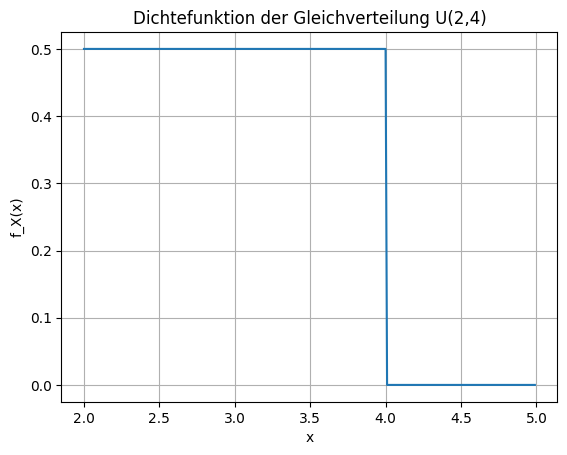

0.5
0.5


In [71]:
# a)
dist = uniform(2, 2) # Verteilungsfunktion zwischen 2 und 4
Density = dist.pdf # Dichtefunktion
n = np.arange(2, 5, 0.01)
plt.plot(n, Density(n))
plt.xlabel("x")
plt.ylabel("f_X(x)")
plt.title("Dichtefunktion der Gleichverteilung U(2,4)")
plt.grid(True)
plt.show()

#b) P(!(X>=3)) = P(X<3) = P(X<=2)
print(f"{dist.cdf(3)}")

# c) X range(5/2,7/2) => P(2.5 <= X <= 3.5)
P = dist.cdf(3.5) - dist.cdf(2.5)
print(P) # delta = 1, len = 2, P = delta/len = 0.5

### Teilaufgabe 6.1.2

In [79]:
mean = dist.mean() # Erwartungswert
print(mean)
var = dist.var() # Varianz
print(f"{var:.4f}")
std = dist.std() # Standardabweichung
print(f"{std:.4f}")

3.0
0.3333
0.5774


### Teilaufgabe 6.1.3

In [82]:
median = dist.median() # Median
print(median)
ninety_quantile = dist.ppf(0.9) # 90%-Quantil
print(f"{ninety_quantile:.4f}")

3.0
3.8000


## Aufgabe 6.2
### Teilaufgabe 6.2.1

In [11]:
f_A = lambda x : (
    0 if x < 0 else
    (3/2)*x**2 + x if 0 <= x <= 1 else
    0
)
f_B = lambda x : (
    0 if x < 2 else
    3/(x**2) if 2 <= x <= 6 else
    0
)
F_A = lambda x : (
    0 if x < 0 else
    3/6*x**3 + 1/2*x**2 if 0 <= x <= 1 else
    1
)  # Verteilungsfunktion F_A(X)
F_B = lambda x: (
    0 if x < 2 else
    (3/2 - 3/x) if 2 <= x <= 6 else
    1
)  # Verteilungsfunktion F_B(X)

### Teilaufgabe 6.2.2

In [12]:
# a) P(A=0.5)
#P_a = f_A(0.5) # 0 => bei EINEM Punkt bei stet. IMMER 0
# b) P(A<=0.5)
P_b = F_A(0.5) # cdf => kumulative Verteilungsfunktion BIS Punkt
# c) P(B<=6)
P_c = F_B(6)
# d) P(B>4)
P_d = 1 - F_B(4)
print(f"P(A=0.5) = {0}, P(A<=0.5) = {P_b:.4f}, P(B<=6) = {P_c:.4f}, P(B>4) = {P_d:.4f}")

P(A=0.5) = 0, P(A<=0.5) = 0.1875, P(B<=6) = 1.0000, P(B>4) = 0.2500


### Teilaufgabe 6.2.3

In [106]:
E_A, _ = quad(lambda x : x * f_A(x), 0, 1)
E_B, _ = quad(lambda x : x * f_B(x), 2, 6)
print(f"E(A) = {E_A:.4f}, E(B) = {E_B:.4f}")

E(A) = 0.7083, E(B) = 3.2958
